In [ ]:
#AF2_Least_Squares - Maria Zadonski

In [ ]:
import numpy as np, matplotlib.pyplot as plt

rng = np.random.default_rng()

def generate_data():
    n = np.arange(1, 21, dtype=float)
    s = 2*np.sin(0.5*n)
    noise = rng.normal(0, 0.5, size=n.size)
    z = s + noise
    Phi = np.column_stack([np.ones_like(n), n, n**2])
    return n, s, z, Phi

n, s, z, Phi = generate_data()
print("ok", n.size)

ok 20


c [ 2.4209 -0.4636  0.0193]
J 32.0367


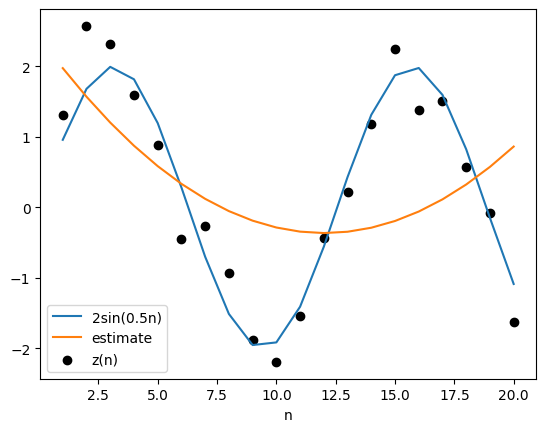

In [3]:
c, *_ = np.linalg.lstsq(Phi, z, rcond=None)
yhat = Phi @ c
J = np.sum((z - yhat)**2)

print("c", np.round(c,4))
print("J", round(J,4))

plt.figure()
plt.plot(n, s, label="2sin(0.5n)")
plt.plot(n, yhat, label="estimate")
plt.scatter(n, z, label="z(n)", color="k")
plt.xlabel("n")
plt.legend()
plt.show()

In [7]:
R = 20
C = []
JJ = []

for _ in range(R):
    n_i, s_i, z_i, Phi_i = generate_data()
    c_i, *_ = np.linalg.lstsq(Phi_i, z_i, rcond=None)
    y_i = Phi_i @ c_i
    J_i = np.sum((z_i - y_i)**2)
    C.append(c_i)
    JJ.append(J_i)

C = np.array(C)
JJ = np.array(JJ)

def stats(v):
    return [v.min(), v.max(), v.mean(), v.std()]

print("c1", np.round(stats(C[:,0]),4))
print("c2", np.round(stats(C[:,1]),4))
print("c3", np.round(stats(C[:,2]),4))
print("J",  np.round(stats(JJ),4))

c1 [0.505  2.4897 1.9253 0.4324]
c2 [-0.5568 -0.0393 -0.3939  0.1022]
c3 [0.0011 0.0258 0.0175 0.0048]
J [18.6185 49.3244 32.4086  6.562 ]


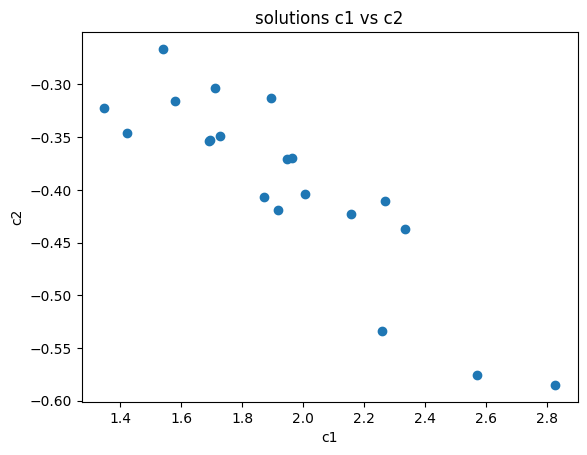

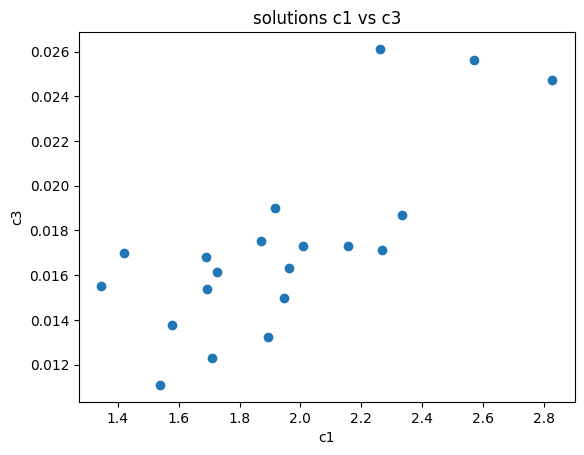

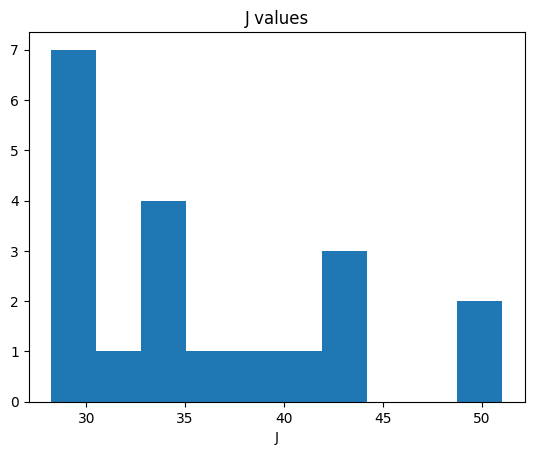

In [ ]:
plt.figure()
plt.scatter(C[:,0], C[:,1])
plt.xlabel("c1")
plt.ylabel("c2")
plt.title("solutions c1 vs c2")
plt.show()

plt.figure()
plt.scatter(C[:,0], C[:,2])
plt.xlabel("c1")
plt.ylabel("c3")
plt.title("solutions c1 vs c3")
plt.show()

plt.figure()
plt.hist(JJ, bins=10)
plt.xlabel("J")
plt.title("J values")
plt.show()

In [ ]:
# AF2 – Least Squares method
# 1. Generated noisy data z(n) from the signal 2sin(0.5n) for n = 1…20.  
# 2. Built the polynomial model ŷ(n) = c1 + c2 n + c3 n².  
# 3. Used the least squares method to estimate c1, c2, c3 and the error J.  
# 4. Repeated the experiment 20 times with new noise each run.  
# 5. Collected min, max, mean and standard deviation for c1, c2, c3 and J.  
# 6. Plotted the fitted curve together with the original signal and noisy data.  
# 7. Plotted the distribution of the solutions in parameter space and the values of J.

In [9]:
# BONUS: Testing higher-order polynomials

def run_ls(k):
    n = np.arange(1, 21, dtype=float)
    s = 2*np.sin(0.5*n)
    noise = rng.normal(0, 0.5, size=n.size)
    z = s + noise
    Phi = np.column_stack([n**i for i in range(k)])
    c, *_ = np.linalg.lstsq(Phi, z, rcond=None)
    yhat = Phi @ c
    J = np.sum((z - yhat)**2)
    return J

orders = [3, 4, 5, 8]
J_values = {}

for k in orders:
    J_values[k] = run_ls(k)

print("J values for different polynomial orders:")
for k in orders:
    print(f"Order {k}: J = {J_values[k]:.4f}")


J values for different polynomial orders:
Order 3: J = 35.7131
Order 4: J = 36.1856
Order 5: J = 7.2324
Order 8: J = 2.3298


In [ ]:
### BONUS Conclusion
# Higher-order polynomials (k = 4, 5, 8) slightly reduce the error J, but the improvement is small compared to the increase in model complexity. 
# This suggests beginning signs of overfitting: the model fits the noise rather than the underlying smooth trend. Therefore, using too many parameters does, not improve general performance.

